Ejercicio de evaluación Módulo 3
Fase 2: Análisis Estadístico

In [1]:
# importamos las librerías que necesitamos
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None) # para poder visualizar todas las columnas de los DataFrames

In [2]:
df = pd.read_csv("files/customer_flight_activity_limpio.csv") # para cargar el archivo CSV "customer_flight_activity.csv" en un DataFrame llamado df, lo que nos permitirá trabajar con los datos de actividad de los clientes de vuelos en Python utilizando la biblioteca pandas.

In [3]:
df.head() # para visualizar las primeras filas del DataFrame df, lo que puede ayudar a verificar que los cambios realizados en la columna "Salary" se han aplicado correctamente y a obtener una vista general de los datos actualizados.

,loyalty_number,province,city,postal_code,gender,education,salary,marital_status,loyalty_card,clv,enrollment_type,enrollment_year,enrollment_month,cancellation_year,cancellation_month,year,month,flights_booked,flights_with_companions,total_flights,distance,points_accumulated,points_redeemed,dollar_cost_points_redeemed,status
0,480934,Ontario,Toronto,M2Z 4K1,Female,Bachelor,83236,Married,Star,3839.14,Standard,2016,2,NaN,NaN,2017,1,0,0,0,0,0.0,0,0,active
1,480934,Ontario,Toronto,M2Z 4K1,Female,Bachelor,83236,Married,Star,3839.14,Standard,2016,2,NaN,NaN,2017,2,3,0,3,2823,282.0,0,0,active
2,480934,Ontario,Toronto,M2Z 4K1,Female,Bachelor,83236,Married,Star,3839.14,Standard,2016,2,NaN,NaN,2017,3,0,0,0,0,0.0,0,0,active
3,480934,Ontario,Toronto,M2Z 4K1,Female,Bachelor,83236,Married,Star,3839.14,Standard,2016,2,NaN,NaN,2017,4,0,0,0,0,0.0,0,0,active
4,480934,Ontario,Toronto,M2Z 4K1,Female,Bachelor,83236,Married,Star,3839.14,Standard,2016,2,NaN,NaN,2018,10,6,2,8,3352,335.0,465,38,active


Análisis variables numéricas. Interpretación en exploración.md

In [4]:
df.describe().T # para obtener estadísticas descriptivas de todas las columnas numéricas

,count,mean,std,min,25%,50%,75%,max
loyalty_number,403760.0,549875.383713,258961.514684,100018.00,326699.00,550598.00,772152.00,999986.00
salary,403760.0,76174.022761,30506.537333,9081.00,63901.00,66746.00,82940.00,407228.00
clv,403760.0,7990.864857,6863.317160,1898.01,3981.78,5776.34,8937.12,83325.38
enrollment_year,403760.0,2015.250716,1.979427,2012.00,2014.00,2015.00,2017.00,2018.00
enrollment_month,403760.0,6.667555,3.398829,1.00,4.00,7.00,10.00,12.00
cancellation_year,49650.0,2016.504350,1.380482,2013.00,2016.00,2017.00,2018.00,2018.00
cancellation_month,49650.0,6.962095,3.454362,1.00,4.00,7.00,10.00,12.00
year,403760.0,2017.500352,0.500000,2017.00,2017.00,2018.00,2018.00,2018.00
month,403760.0,6.501335,3.451982,1.00,4.00,7.00,10.00,12.00
flights_booked,403760.0,4.134050,5.230064,0.00,0.00,1.00,8.00,21.00


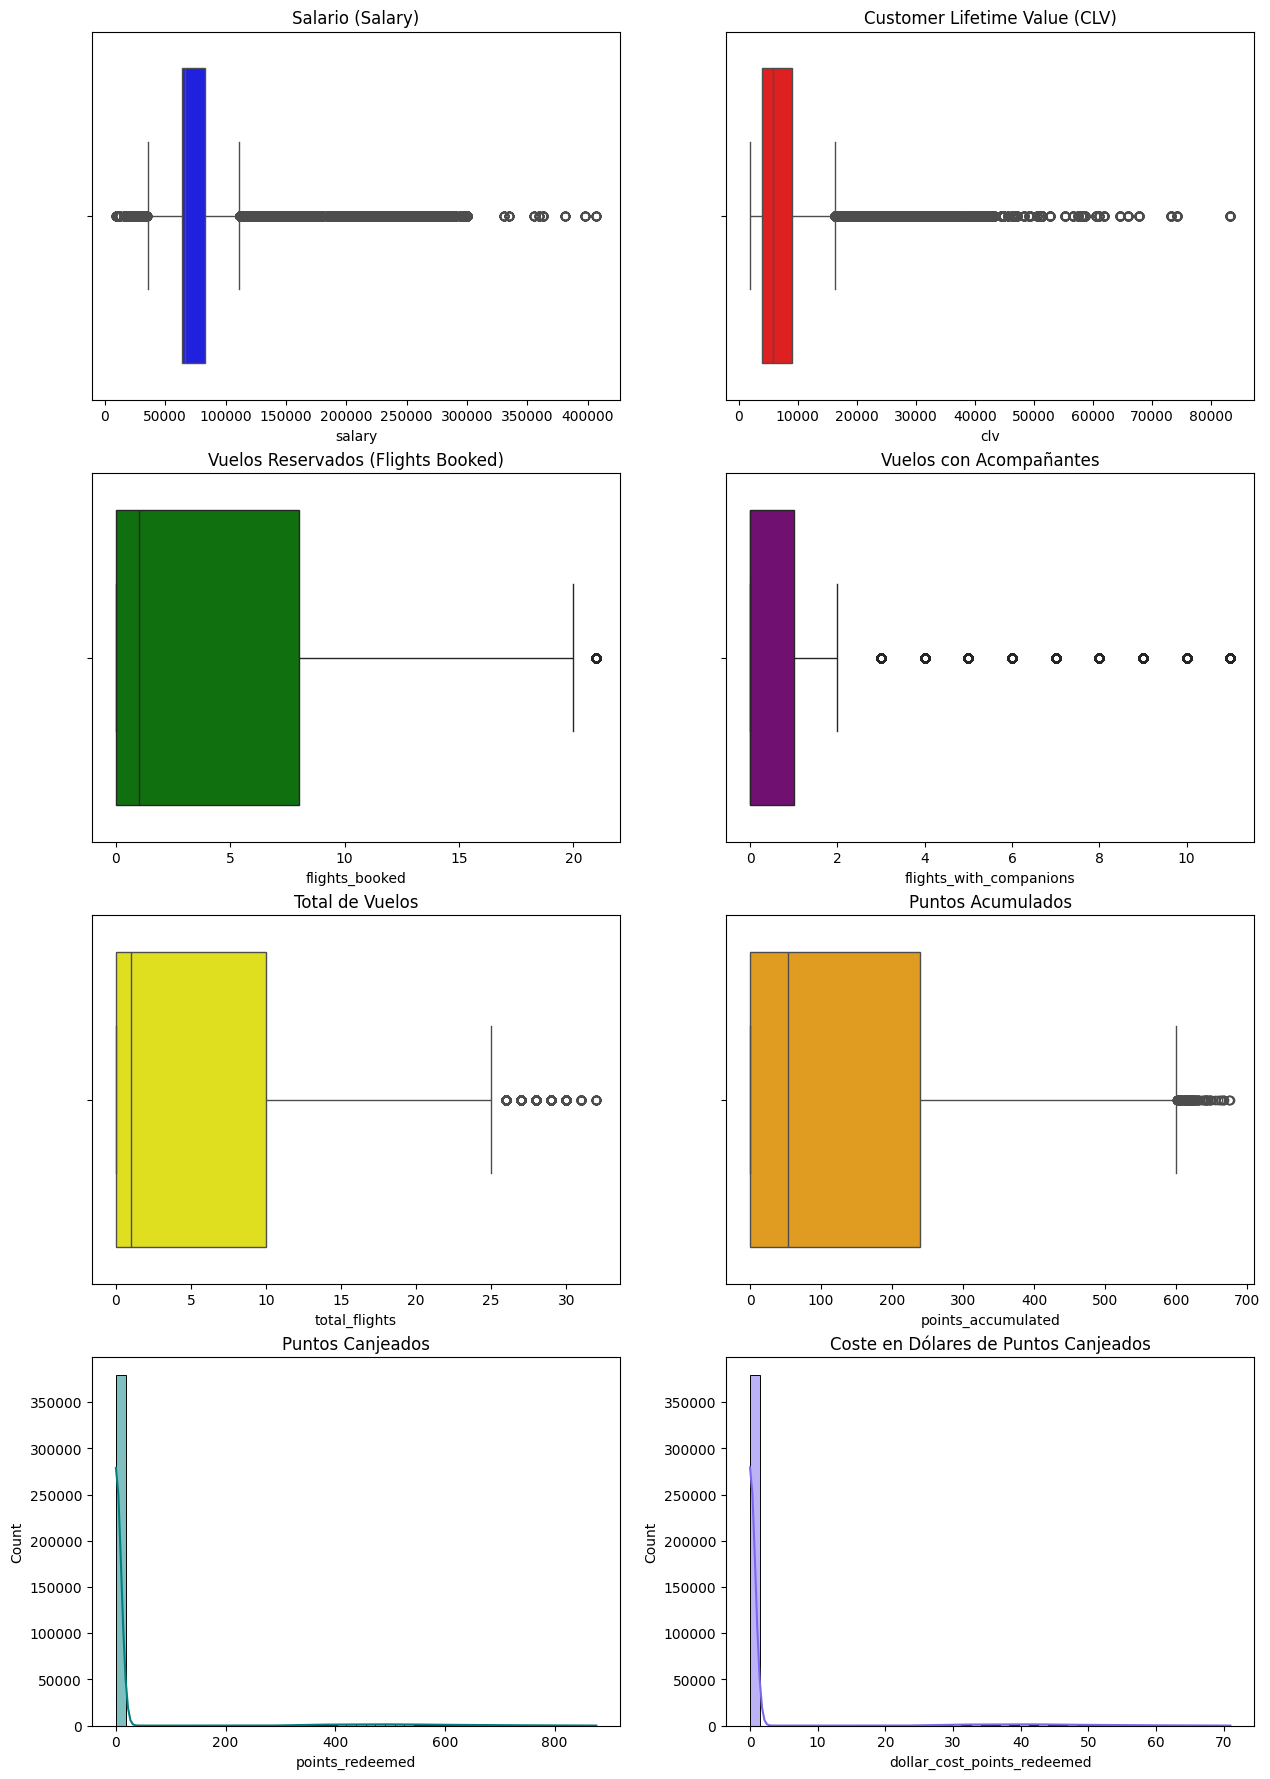

In [5]:
fig, axes = plt.subplots(4, 2, figsize=(15, 22)) # para crear una figura con 4 filas y 2 columnas de subgráficos (axes) utilizando Matplotlib, lo que nos permitirá visualizar múltiples gráficos en una sola figura de manera organizada. El tamaño de la figura se establece en 15 pulgadas de ancho y 22 pulgadas de alto para asegurar que los gráficos sean legibles y estén bien distribuidos.

sns.boxplot(data=df, x="salary", ax=axes[0, 0], color="blue")
axes[0, 0].set_title("Salario (Salary)")

sns.boxplot(data=df, x="clv", ax=axes[0, 1], color="red")
axes[0, 1].set_title("Customer Lifetime Value (CLV)")

sns.boxplot(data=df, x="flights_booked", ax=axes[1, 0], color="green")
axes[1, 0].set_title("Vuelos Reservados (Flights Booked)")

sns.boxplot(data=df, x="flights_with_companions", ax=axes[1, 1], color="purple")
axes[1, 1].set_title("Vuelos con Acompañantes")

sns.boxplot(data=df, x="total_flights", ax=axes[2, 0], color="yellow")
axes[2, 0].set_title("Total de Vuelos")

sns.boxplot(data=df, x="points_accumulated", ax=axes[2, 1], color="orange")
axes[2, 1].set_title("Puntos Acumulados")

sns.histplot(data=df, x="points_redeemed", bins=50, kde=True, ax=axes[3, 0], color="teal")
axes[3, 0].set_title("Puntos Canjeados")

sns.histplot(data=df, x="dollar_cost_points_redeemed", bins=50, kde=True, ax=axes[3, 1], color="mediumslateblue")
axes[3, 1].set_title("Coste en Dólares de Puntos Canjeados");

Análisis de correlación entre variables numéricas. Interpretación en exploración.md

In [6]:
salario_vuelos_totales = df[['salary', 'total_flights']].corr()
salario_vuelos_totales

,salary,total_flights
salary,1.000000,0.003885
total_flights,0.003885,1.000000


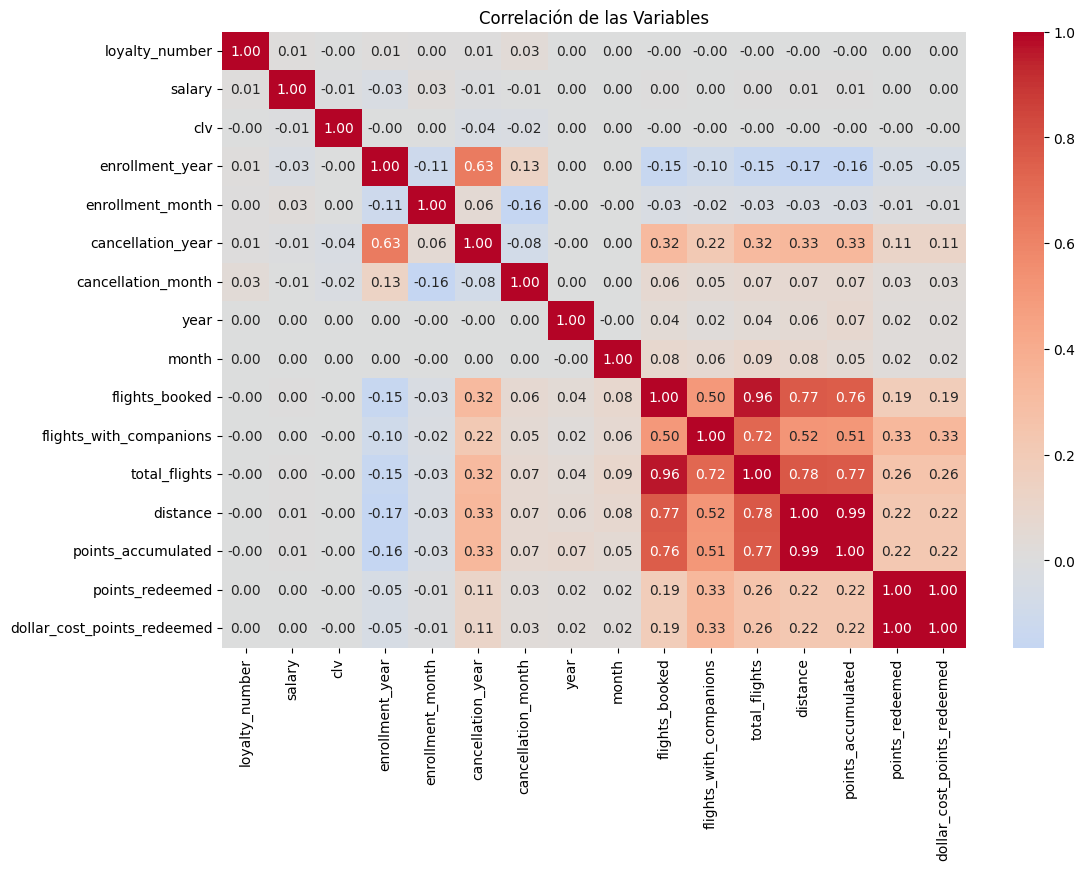

In [7]:
df_numericas = df.select_dtypes(include=['number'])

corr = df_numericas.corr()

plt.figure(figsize=(12, 8))

sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', center=0,)

plt.title("Correlación de las Variables")
plt.show()

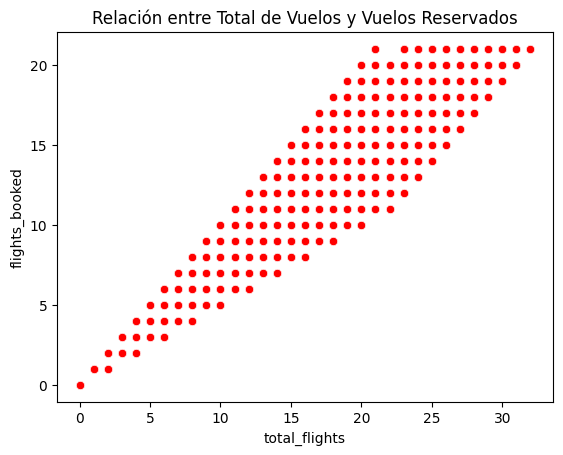

In [10]:
sns.scatterplot(data = df, x="total_flights", y="flights_booked", color= "red")

plt.title("Relación entre Total de Vuelos y Vuelos Reservados");

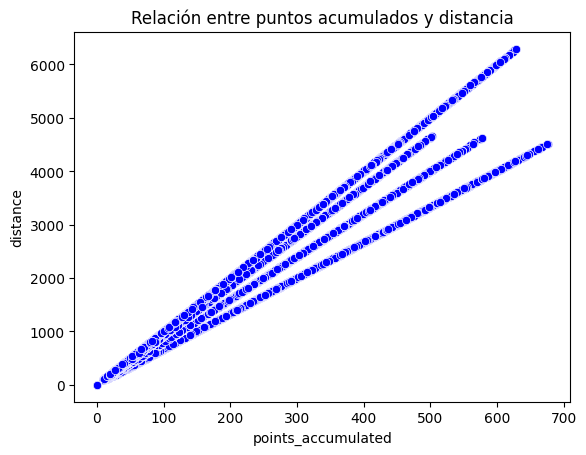

In [12]:
sns.scatterplot(data = df, x="points_accumulated", y="distance", color= "blue")

plt.title("Relación entre puntos acumulados y distancia");

Análisis variables categóricas. Interpretación en exploración.md

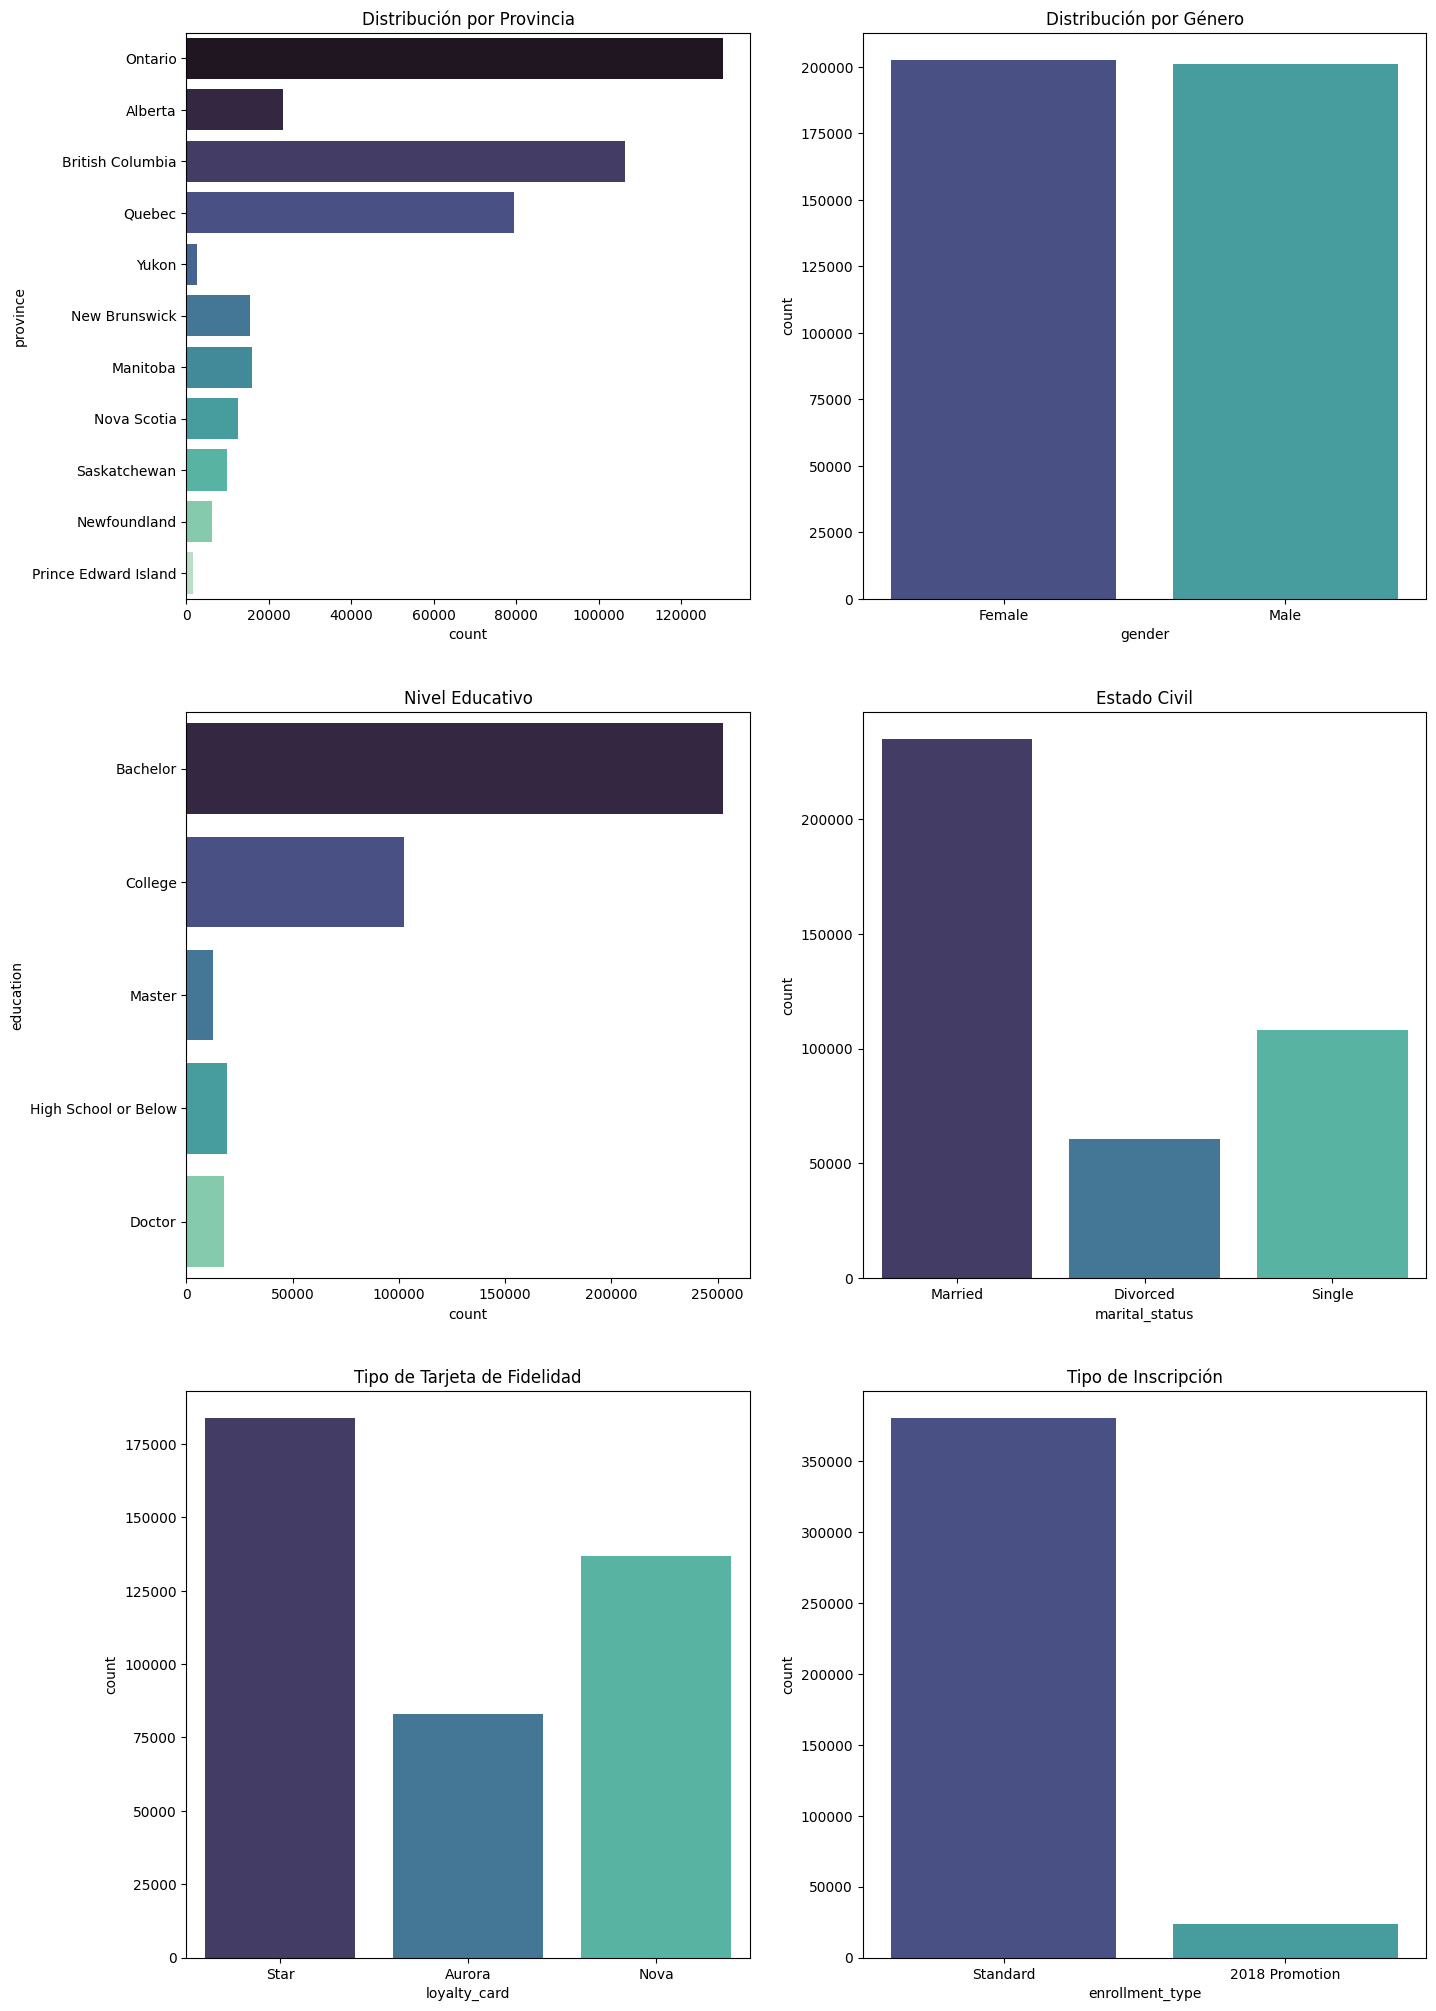

In [40]:
fig, axes = plt.subplots(3, 2, figsize=(16, 25))

sns.countplot(data=df, y="province", ax=axes[0, 0], palette="mako", hue="province", legend=False)
axes[0, 0].set_title("Distribución por Provincia")

sns.countplot(data=df, x="gender", ax=axes[0, 1], palette="mako", hue="gender", legend=False)
axes[0, 1].set_title("Distribución por Género")

sns.countplot(data=df, y="education", ax=axes[1, 0], palette="mako", hue="education", legend=False)
axes[1, 0].set_title("Nivel Educativo")

sns.countplot(data=df, x="marital_status", ax=axes[1, 1], palette="mako", hue="marital_status", legend=False)
axes[1, 1].set_title("Estado Civil")

sns.countplot(data=df, x="loyalty_card", ax=axes[2, 0], palette="mako", hue="loyalty_card", legend=False)
axes[2, 0].set_title("Tipo de Tarjeta de Fidelidad")

sns.countplot(data=df, x="enrollment_type", ax=axes[2, 1], palette="mako", hue="enrollment_type", legend=False)
axes[2, 1].set_title("Tipo de Inscripción");



In [ ]:
df["gender"].value_counts(normalize=True, dropna=False)*100 # para calcular el porcentaje de cada categoría en la columna

gender
Female    50.217208
Male      49.782792
Name: proportion, dtype: float64

In [ ]:
df["education"].value_counts(normalize=True, dropna=False)*100 # para calcular el porcentaje de cada categoría en la columna

education
Bachelor                62.553745
College                 25.326927
High School or Below     4.684714
Doctor                   4.391470
Master                   3.043144
Name: proportion, dtype: float64

In [43]:
df["marital_status"].value_counts(normalize=True, dropna=False)*100 # para calcular el porcentaje de cada categoría en la columna

marital_status
Married     58.164504
Single      26.786457
Divorced    15.049039
Name: proportion, dtype: float64